In [40]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("../../data/DieCasting_Quality_Raw_Data.csv", header=[0,1])

# 상위 5행 확인
df.head()

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   
3               217           0.008                 11  ...           0   
4               217           0.008                 12  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   
3       0      0             0               0          0       0         0   
4       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  
3             0            0  
4             0            0  

[5 rows x 57 columns]

In [41]:
df.describe

<bound method NDFrame.describe of       Process                                                     \
           id Product_Type Shot Velocity_1 Velocity_2 Velocity_3   
0           1            1    1      0.144      0.170      0.188   
1        1002            1    2      0.144      0.170      0.182   
2        2003            1    3      0.144      0.170      0.182   
3        3004            1    4      0.144      0.170      0.182   
4        4005            1    5      0.144      0.172      0.176   
...       ...          ...  ...        ...        ...        ...   
7530  7530659            2  659      0.150      0.166      0.210   
7531  7531660            2  660      0.144      0.174      0.206   
7532  7532660            2  660      0.144      0.174      0.206   
7533  7533661            2  661      0.147      0.174      0.204   
7534  7534661            2  661      0.147      0.174      0.204   

                                                                         ...  \
 

In [42]:
# 1.변수 'Biscuit_Thickness ', 'Clamping_Force ', ' Pressure_Rise_Time' 앞 뒤 공백 제거
df.columns = pd.MultiIndex.from_tuples(
    [(col[0].strip(), col[1].strip()) for col in df.columns]
)

print(df.columns.tolist())

[('Process', 'id'), ('Process', 'Product_Type'), ('Process', 'Shot'), ('Process', 'Velocity_1'), ('Process', 'Velocity_2'), ('Process', 'Velocity_3'), ('Process', 'High_Velocity'), ('Process', 'Cylinder_Pressure'), ('Process', 'Rapid_Rise_Time'), ('Process', 'Biscuit_Thickness'), ('Process', 'Clamping_Force'), ('Process', 'Cycle_Time'), ('Process', 'Pressure_Rise_Time'), ('Process', 'Casting_Pressure'), ('Process', 'Spray_Time'), ('Process', 'Spray_1_Time'), ('Process', 'Spray_2_Time'), ('Sensor', 'Melting_Furnace_Temp'), ('Sensor', 'Air_Pressure'), ('Sensor', 'Air_Pressure_Min'), ('Sensor', 'Air_Pressure_Max'), ('Sensor', 'Coolant_Temp'), ('Sensor', 'Coolant_Temp_Min'), ('Sensor', 'Coolant_Temp_Max'), ('Sensor', 'Coolant_Pressure'), ('Sensor', 'Factory_Temp'), ('Sensor', 'Factory_Temp_Min'), ('Sensor', 'Factory_Temp_Max'), ('Sensor', 'Factory_Humidity'), ('Sensor', 'Factory_Humidity_Min'), ('Sensor', 'Factory_Humidity_Max'), ('Defects', 'Short_Shot_1'), ('Defects', 'Bubble_1'), ('Defe

In [43]:
# 2.factory_cols 결측치 중앙값 처리
factory_cols = [
    'Factory_Temp',
    'Factory_Temp_Min',
    'Factory_Temp_Max',
    'Factory_Humidity',
    'Factory_Humidity_Min',
    'Factory_Humidity_Max'
]

for col in factory_cols:
    df[('Sensor', col)] = df[('Sensor', col)].fillna(
        df[('Sensor', col)].median()
    )

df.isnull().sum().sum()
print("중앙값으로 처리 완료!")

중앙값으로 처리 완료!


In [44]:
for col in df.columns:
    if "Defect" in col[1]:
        print(col)

In [47]:
# defect 관련 컬럼 후보 찾기 (대소문자 무시 + 양쪽 공백 제거 + 두 레벨 모두 탐색)
hits = []
for a, b in df.columns:
    a2 = str(a).strip().lower()
    b2 = str(b).strip().lower()
    if ("defect" in a2) or ("defect" in b2):
        hits.append((a, b))

print("defect 포함 컬럼:", hits)

defect 포함 컬럼: [('Defects', 'Short_Shot_1'), ('Defects', 'Bubble_1'), ('Defects', 'Exfoliation_1'), ('Defects', 'Blow_Hole_1'), ('Defects', 'Stain_1'), ('Defects', 'Dent_1'), ('Defects', 'Deformation_1'), ('Defects', 'Contamination_1'), ('Defects', 'Impurity_1'), ('Defects', 'Crack_1'), ('Defects', 'Scratch_1'), ('Defects', 'Buring_Mark_1'), ('Defects', 'Inclusions_1'), ('Defects', 'Short_Shot_2'), ('Defects', 'Bubble_2'), ('Defects', 'Exfoliation_2'), ('Defects', 'Blow_Hole_2'), ('Defects', 'Stain_2'), ('Defects', 'Dent_2'), ('Defects', 'Deformation_2'), ('Defects', 'Contamination_2'), ('Defects', 'Impurity_2'), ('Defects', 'Crack_2'), ('Defects', 'Scratch_2'), ('Defects', 'Buring_Mark_2'), ('Defects', 'Inclusions_2')]


In [49]:
# 3. Defects 컬럼 1을 초과하는 값 1(불량)으로 대체
defect_cols = [col for col in df.columns if col[0] == "Defects"]

print("불량이 포함된 Defects 컬럼 수:", len(defect_cols))

# 값 1 초과 → 1
df[defect_cols] = df[defect_cols].clip(upper=1)

print("불량값 1대체")

불량이 포함된 Defects 컬럼 수: 26
불량값 1대체


In [50]:
# 결측치 처리 확인
df.isna().sum()

Process  id                      0
         Product_Type            0
         Shot                    0
         Velocity_1              0
         Velocity_2              0
         Velocity_3              0
         High_Velocity           0
         Cylinder_Pressure       0
         Rapid_Rise_Time         0
         Biscuit_Thickness       0
         Clamping_Force          0
         Cycle_Time              0
         Pressure_Rise_Time      0
         Casting_Pressure        0
         Spray_Time              0
         Spray_1_Time            0
         Spray_2_Time            0
Sensor   Melting_Furnace_Temp    0
         Air_Pressure            0
         Air_Pressure_Min        0
         Air_Pressure_Max        0
         Coolant_Temp            0
         Coolant_Temp_Min        0
         Coolant_Temp_Max        0
         Coolant_Pressure        0
         Factory_Temp            0
         Factory_Temp_Min        0
         Factory_Temp_Max        0
         Factory_Hum

[이상치 분석]

In [51]:
df.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                         ...      Defects                                     \
      Biscuit_Thickness  ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count       7535.000000  ...  7535.000000  7535.0  7535.000000   7535.000000   
mean          14.309622  ...     0.020571     0.0     0.000531      0.008494   
std            3.286284  ...     0.141951     0.0     0.023036      0.091775   
min            0.000000  ...     0.000000     0.0     0.000000      0.000000   
25%           11.000000  ...     0.000000     0.0     0.000000      0.000000   
50%           13.000000  ...     0.000000     0.0     0.000000      0.000000   
75%           17.000000  ...     0.000000     0.0     0.000000      0.000000   
max           24.000000  ...     1.000000     0.0     1.000000      1.000000   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     7535.000000  7535.000000  7535.000000    7535.0        7535.0   
mean         0.001062     0.000664     0.000265       0.0           0.0   
std          0.032569     0.025753     0.016291       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  7535.000000  
mean      0.000133  
std       0.011520  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

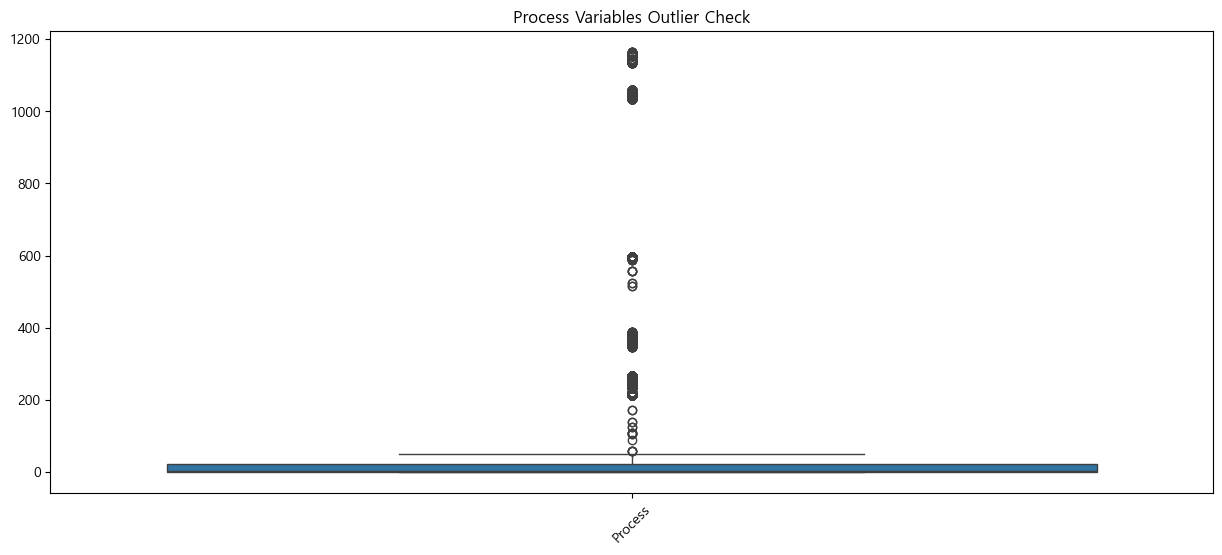

In [66]:
process_cols = [
    col for col in df.columns
    if col[0] == "Process"
    and col[1] not in ["id", "Shot"]
]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

sns.boxplot(data=df[[c for c in process_cols]])

plt.xticks(rotation=45)
plt.title("Process Variables Outlier Check")

plt.show()

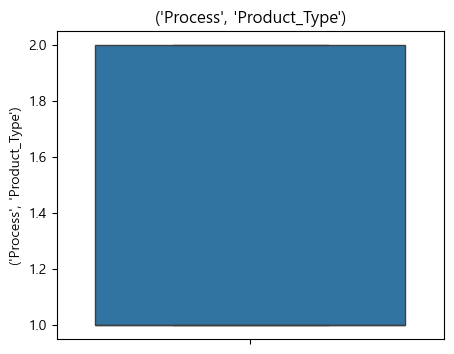

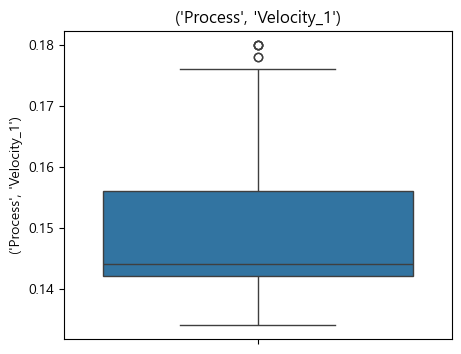

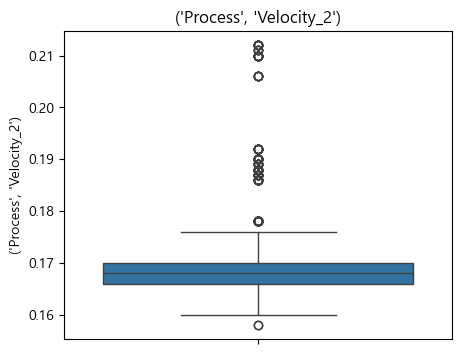

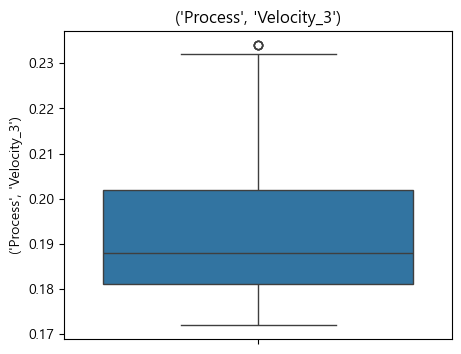

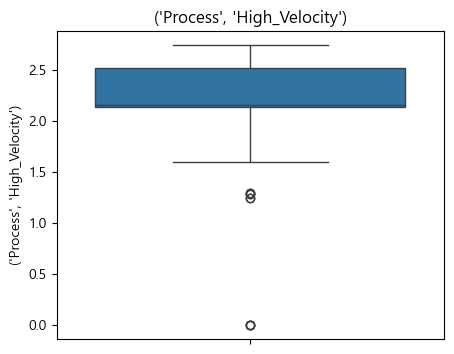

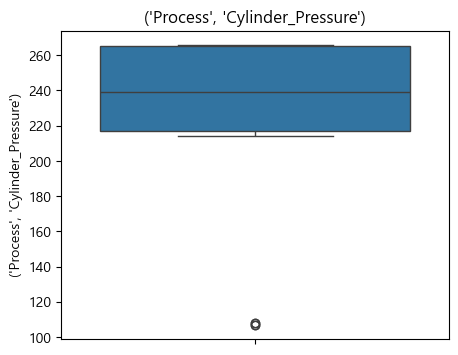

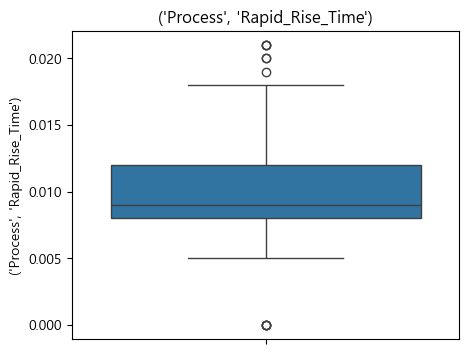

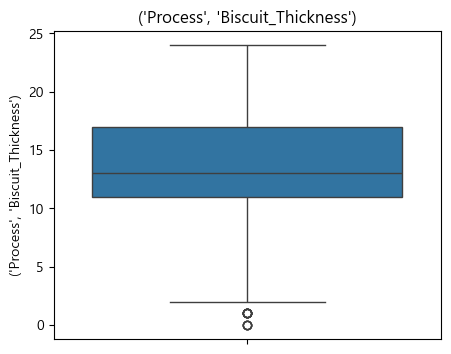

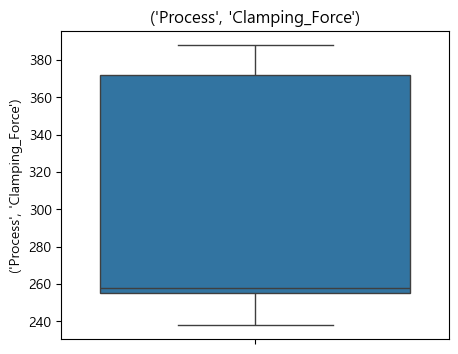

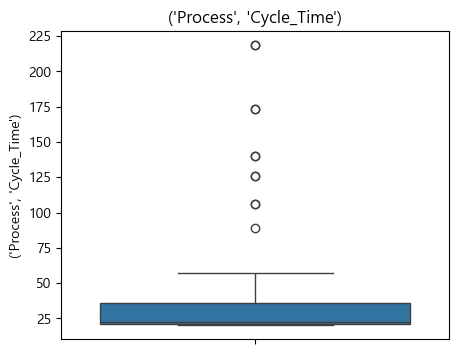

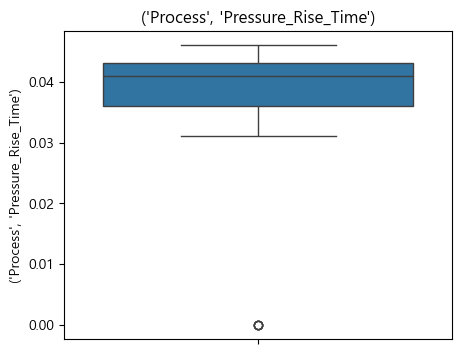

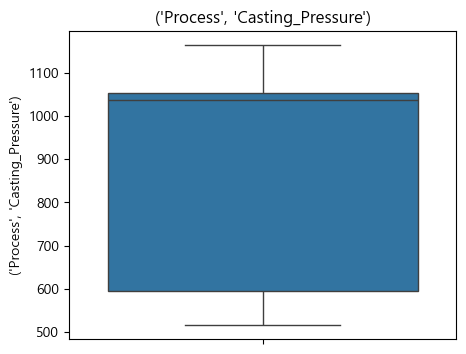

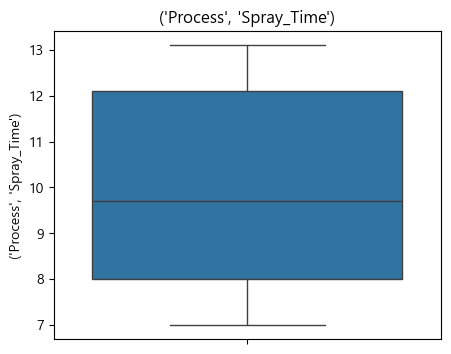

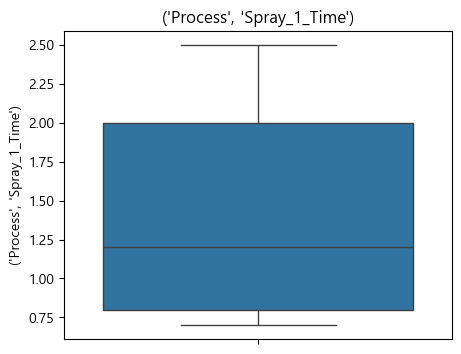

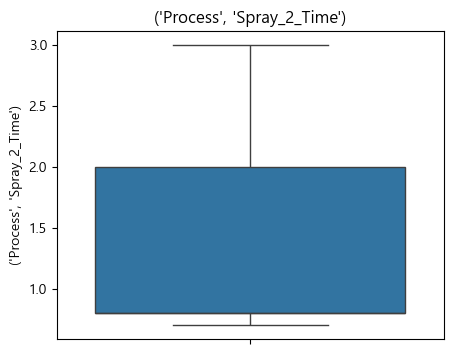

In [67]:
for col in process_cols:
    
    plt.figure(figsize=(5,4))
    
    sns.boxplot(y=df[col])
    
    plt.title(col)
    
    plt.show()

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_GROUPS = ["Process"]

# 보통 제외하는 컬럼 (식별자/순번/범주형)
EXCLUDE_SUBCOLS = {"id", "Shot", "Product_Type"}

target_cols = [
    c for c in df.columns
    if c[0] in TARGET_GROUPS and c[1] not in EXCLUDE_SUBCOLS
]


# 숫자형으로 강제 변환(문자 섞인 컬럼 대비)
df_num = df[target_cols].apply(pd.to_numeric, errors="coerce")

print("분석 대상 컬럼 수:", df_num.shape[1])
print("전체 결측 비율(%) 평균:", (df_num.isna().mean().mean() * 100).round(2))


# 1) IQR 기반 이상치 탐지
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

is_out_iqr = (df_num.lt(lower) | df_num.gt(upper))  # DataFrame[bool]

iqr_outlier_count = is_out_iqr.sum().sort_values(ascending=False)
iqr_outlier_rate = (is_out_iqr.mean() * 100).sort_values(ascending=False)

iqr_summary = pd.DataFrame({
    "이상치 갯수": iqr_outlier_count,
    "이상치 비율(%)": iqr_outlier_rate.round(3),
    "하한선": lower,
    "상한선": upper,
    "Q1(25%)": Q1,
    "Q3(75%)": Q3,
    "IQR": IQR
}).sort_values("이상치 비율(%)", ascending=False)

print("\n[IQR 이상치 TOP 15]")
display(iqr_summary.head(15))


분석 대상 컬럼 수: 14
전체 결측 비율(%) 평균: 0.0

[IQR 이상치 TOP 15]


이상치 갯수  이상치 비율(%)       하한선        상한선  Q1(25%)  \
Process Velocity_2             184      2.442    0.1600     0.1760    0.166   
        Biscuit_Thickness       12      0.159    2.0000    26.0000   11.000   
        Cycle_Time              11      0.146   -1.6000    58.4000   20.900   
        High_Velocity           10      0.133    1.5505     3.1065    2.134   
        Rapid_Rise_Time         10      0.133    0.0020     0.0180    0.008   
        Velocity_1               6      0.080    0.1210     0.1770    0.142   
        Velocity_3               4      0.053    0.1495     0.2335    0.181   
        Pressure_Rise_Time       4      0.053    0.0255     0.0535    0.036   
        Cylinder_Pressure        4      0.053  145.0000   337.0000  217.000   
        Casting_Pressure         0      0.000  -89.5000  1738.5000  596.000   
        Clamping_Force           0      0.000   79.5000   547.5000  255.000   
        Spray_1_Time             0      0.000   -1.0000     3.8000    0.800   
        Spray_2_Time             0      0.000   -1.0000     3.8000    0.800   
        Spray_Time               0      0.000    1.8500    18.2500    8.000   

                             Q3(75%)      IQR  
Process Velocity_2             0.170    0.004  
        Biscuit_Thickness     17.000    6.000  
        Cycle_Time            35.900   15.000  
        High_Velocity          2.523    0.389  
        Rapid_Rise_Time        0.012    0.004  
        Velocity_1             0.156    0.014  
        Velocity_3             0.202    0.021  
        Pressure_Rise_Time     0.043    0.007  
        Cylinder_Pressure    265.000   48.000  
        Casting_Pressure    1053.000  457.000  
        Clamping_Force       372.000  117.000  
        Spray_1_Time           2.000    1.200  
        Spray_2_Time           2.000    1.200  
        Spray_Time            12.100    4.100

In [78]:
top9_cols = iqr_summary.head(9).index

for col in top9_cols:
    
    lower_val = lower[col]
    upper_val = upper[col]
    
    outliers = df[(df[col] < lower_val) | (df[col] > upper_val)][col]
    
    mean_val = df[col].mean()
    
    print("="*40)
    print(col)
    
    print("이상치 개수:", len(outliers))
    print("최소:", outliers.min())
    print("최대:", outliers.max())
    
    print("평균 대비 최소:", (outliers.min()-mean_val)/mean_val*100, "%")
    print("평균 대비 최대:", (outliers.max()-mean_val)/mean_val*100, "%")

('Process', 'Velocity_2')
이상치 개수: 184
최소: 0.158
최대: 0.212
평균 대비 최소: -6.398398631351833 %
평균 대비 최대: 25.59202208957855 %
('Process', 'Biscuit_Thickness')
이상치 개수: 12
최소: 0
최대: 1
평균 대비 최소: -100.0 %
평균 대비 최대: -93.01169509288371 %
('Process', 'Cycle_Time')
이상치 개수: 11
최소: 89.1
최대: 218.6
평균 대비 최소: 221.24339563597593 %
평균 대비 최대: 688.1459740294539 %
('Process', 'High_Velocity')
이상치 개수: 10
최소: 0.0
최대: 1.295
평균 대비 최소: -100.0 %
평균 대비 최대: -44.16202596025957 %
('Process', 'Rapid_Rise_Time')
이상치 개수: 10
최소: 0.0
최대: 0.021
평균 대비 최소: -100.0 %
평균 대비 최대: 118.8347070863528 %
('Process', 'Velocity_1')
이상치 개수: 6
최소: 0.178
최대: 0.18
평균 대비 최소: 20.092583472865176 %
평균 대비 최대: 21.44193834334681 %
('Process', 'Velocity_3')
이상치 개수: 4
최소: 0.234
최대: 0.234
평균 대비 최소: 22.389524641165945 %
평균 대비 최대: 22.389524641165945 %
('Process', 'Pressure_Rise_Time')
이상치 개수: 4
최소: 0.0
최대: 0.0
평균 대비 최소: -100.0 %
평균 대비 최대: -100.0 %
('Process', 'Cylinder_Pressure')
이상치 개수: 4
최소: 107
최대: 108
평균 대비 최소: -55.352598979402536 %
평균 대비 최대: -54.9353

Velocity_1	   :     1차 사출 속도	


Velocity_2	   :     2차 사출 속도	


Velocity_3	   :     3차 사출 속도	


High_Velocity	:    고속 사출 속도	


Cylinder_Pressure :	실린더 압력	


Pressure_Rise_Time :	압력 상승 시간	


Rapid_Rise_Time	 :   급격 상승 시간	


Biscuit_Thickness :	비스킷 두께	


Cycle_Time	   :     사이클 타임

In [ ]:
# 2) Z-score 기반 이상치 탐지(보조 지표)
# 분포가 심하게 치우친 변수는 Z-score가 과민/둔감할 수 있어 "참고용"
z = (df_num - df_num.mean()) / df_num.std(ddof=0)
Z_TH = 3.0
is_out_z = z.abs() > Z_TH

z_outlier_count = is_out_z.sum().sort_values(ascending=False)
z_outlier_rate = (is_out_z.mean() * 100).sort_values(ascending=False)

z_summary = pd.DataFrame({
    "outlier_count": z_outlier_count,
    "outlier_rate_%": z_outlier_rate.round(3),
}).sort_values("outlier_rate_%", ascending=False)

print("\n[Z-score(|z|>3) 이상치 TOP 15]")
display(z_summary.head(15))

In [ ]:
# -----------------------------
# 3) 변수 1개 골라서 '진짜 이상치' 눈으로 확인(추천 함수)
# -----------------------------
def outlier_report_one(col, method="iqr"):
    """
    col: 멀티인덱스 컬럼 튜플 예) ('Process','Velocity_1')
    method: 'iqr' or 'z'
    """
    s = pd.to_numeric(df[col], errors="coerce")

    if method == "iqr":
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5*iqr
        hi = q3 + 1.5*iqr
        mask = (s < lo) | (s > hi)
        title = f"{col} | IQR outliers: {mask.sum()} ({(mask.mean()*100):.2f}%)  bounds=({lo:.3g},{hi:.3g})"
    else:
        zz = (s - s.mean()) / s.std(ddof=0)
        mask = zz.abs() > Z_TH
        title = f"{col} | Z>|{Z_TH}| outliers: {mask.sum()} ({(mask.mean()*100):.2f}%)"

    # 상/하위 극단값 확인
    extremes = pd.concat([s.nsmallest(5), s.nlargest(5)]).dropna()

    print(title)
    print("\n[극단값 10개(작은 5 + 큰 5)]")
    print(extremes)

    # 시각화: 히스토그램 + 박스플롯(각각)
    plt.figure(figsize=(7,4))
    plt.hist(s.dropna(), bins=40)
    plt.title(f"Histogram: {col}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4,4))
    plt.boxplot(s.dropna(), vert=True)
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4) 이상치가 많은 변수 하나 바로 찍어보기(예시)
# -----------------------------
# IQR 기준 TOP 1 변수 자동 선택
top1_col = iqr_summary.index[0]
outlier_report_one(top1_col, method="iqr")

[불량률 분석]

In [53]:
# product_type 별 데이터 분리
product_cols = [c for c in df.columns if str(c[1]).strip().lower() == "product_type"]
if not product_cols:
    raise ValueError("Product_Type 컬럼을 찾지 못했습니다. df.columns를 확인하세요.")

product_col = product_cols[0]
print("Product_Type 컬럼:", product_col)
print(df[product_col].value_counts(dropna=False))

Product_Type 컬럼: ('Process', 'Product_Type')
(Process, Product_Type)
1    4207
2    3328
Name: count, dtype: int64


In [54]:
# Product_Type별 불량 컬럼 불량률 확인
product_col = ('Process', 'Product_Type')

defect_rate = df.groupby(product_col)[defect_cols].mean()

print(defect_rate.head())

                             Defects                                      \
                        Short_Shot_1  Bubble_1 Exfoliation_1 Blow_Hole_1   
(Process, Product_Type)                                                    
1                           0.034704  0.016877      0.041122    0.000000   
2                           0.105469  0.000300      0.000000    0.066406   

                                                                           \
                          Stain_1    Dent_1 Deformation_1 Contamination_1   
(Process, Product_Type)                                                     
1                        0.000713  0.000713      0.025671        0.000000   
2                        0.055889  0.001202      0.000000        0.001202   

                                            ...                                \
                        Impurity_1 Crack_1  ... Blow_Hole_2 Stain_2    Dent_2   
(Process, Product_Type)                     ...                        

<Figure size 1800x600 with 0 Axes>

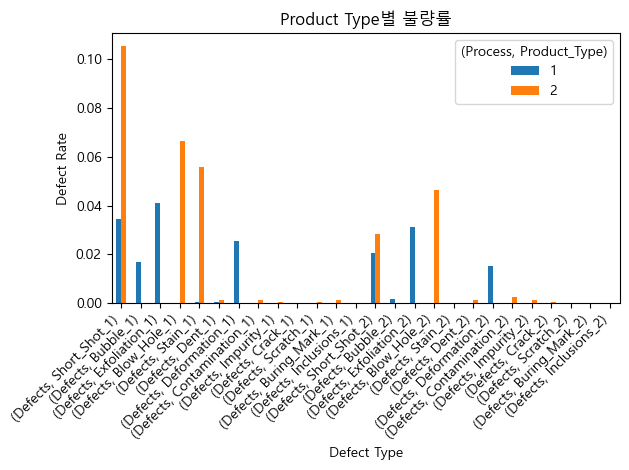

In [63]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(18,6))

defect_rate.T.plot(kind='bar')

plt.title("Product Type별 불량률")
plt.ylabel("Defect Rate")
plt.xlabel("Defect Type")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<Figure size 1800x600 with 0 Axes>

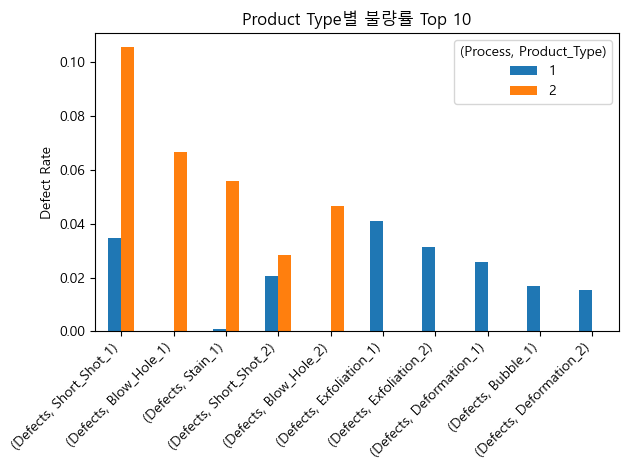

In [64]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

top_defects = defect_rate.mean().sort_values(ascending=False).head(10).index

plt.figure(figsize=(18,6))
defect_rate[top_defects].T.plot(kind='bar')

plt.title("Product Type별 불량률 Top 10")
plt.ylabel("Defect Rate")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# 센서 변수
sensor_cols = [
    "Melting_Furnace_Temp", "Air_Pressure", "Coolant_Temp",
    "Coolant_Pressure", "Factory_Temp", "Factory_Humidity"
]

plt.figure(figsize=(10,5))
df[sensor_cols].boxplot(rot=90)
plt.title("Sensor Variables Boxplot")
plt.show()